In [1]:
import jaxoplanet
import jax.numpy as jnp
import jax
from jaxoplanet.starry import ylm
from jaxoplanet.starry.surface import Surface
from jaxoplanet.starry.visualization import show_surface
import numpy as np

import matplotlib.pyplot as plt

# Latitude integrals

In [2]:
def log_factorial(x):
    return jax.lax.lgamma(x+1.0)

In [3]:
log_factorial(5)

W0407 16:12:45.677552 1308318 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Array(4.7874928, dtype=float32, weak_type=True)

In [4]:
def clmmpi(l, m, mp, i):
    """The Wigner-d matrix coefficients c^l_{m, m', i}."""
    if (m-mp-i) % 2 != 0:
        return 0.0
    elif i < max([0, m+mp, -m-mp]):
        return 0.0
    elif i > min([2*l, 2*l+m-mp,2*l-m+mp]):
        return 0.0
    else:
        log_num = 0.5 * (log_factorial(l - m) + log_factorial(l + m) + 
                      log_factorial(l - mp) + log_factorial(l + mp))
        log_denom = l * jnp.log(2) + log_factorial((i - m - mp) / 2) + \
            log_factorial((i + m + mp) / 2) + log_factorial((2*l - i - m + mp) / 2) + \
            log_factorial((2*l - i + m - mp) / 2)
        if (2*l - m + mp - i)/2 % 2 == 0:
            return jnp.exp(log_num - log_denom)
        else:
            return -jnp.exp(log_num - log_denom)
    

In [5]:
clmmpi(5,-4,0,7)

0.0

In [6]:
jax.scipy.special.hyp2f1(-1 / 2, 0, 5 + 0 - 1 / 2, -1)

Array(1., dtype=float32)

In [7]:
def qlphi(alpha, beta, l, i):
    if (i % 2) != 0:
        return 0.0
    else:
        term1 = jax.lax.lgamma(alpha) + jax.lax.lgamma(l + beta - i/2) \
            - jax.lax.lgamma(l + alpha + beta - i/2)
        term2 = jax.scipy.special.hyp2f1(-i / 2, alpha, l + alpha + beta - i / 2, -1)

        return jnp.exp(term1) * term2

In [8]:
[qlphi(10.0,10.0,5,ii) for ii in range(11)]

[Array(5.0987804e-08, dtype=float32),
 0.0,
 Array(1.2382768e-07, dtype=float32),
 0.0,
 Array(3.1993372e-07, dtype=float32),
 0.0,
 Array(8.858466e-07, dtype=float32),
 0.0,
 Array(2.6508062e-06, dtype=float32),
 0.0,
 Array(8.658424e-06, dtype=float32)]

In [9]:
def plphim(l, m, ebar, alpha, beta, mu=0):
    term1 = jnp.exp(jax.lax.lgamma(alpha + beta) - (jax.lax.lgamma(alpha) + jax.lax.lgamma(beta)))
    sumterm = sum([clmmpi(l, m, 0, i) * qlphi(alpha, beta, l, i) for i in range(0, 2*l+1)])
    term2 = ebar[l] * jnp.exp(1j * jnp.pi * m / 2) * sumterm 

    return term1 * term2

In [57]:
plphim(5,3,ebar,96.0,5.0)

Array(-0.+0.j, dtype=complex64)

In [ ]:
l = 5
m = 3
er = ylm.ylm_spot(l)(contrast=0.1, r=0.1) # defaulted at lon = lat = 0

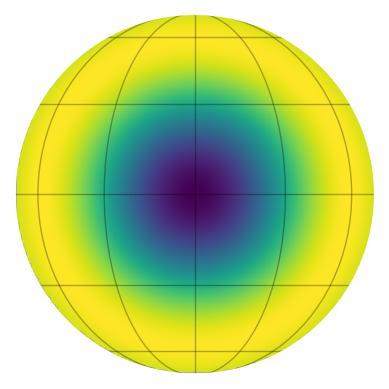

In [55]:
spot_surface = Surface(y=er, inc=jnp.pi/2, obl = 0.0)
show_surface(spot_surface)

In [12]:
er.data

{(0, 0): Array(0.99931526, dtype=float32),
 (1, -1): Array(0., dtype=float32),
 (1, 0): Array(-0.00087294, dtype=float32),
 (1, 1): Array(0., dtype=float32),
 (2, -2): Array(0., dtype=float32),
 (2, -1): Array(0., dtype=float32),
 (2, 0): Array(-0.00106236, dtype=float32),
 (2, 1): Array(0., dtype=float32),
 (2, 2): Array(0., dtype=float32),
 (3, -3): Array(0., dtype=float32),
 (3, -2): Array(0., dtype=float32),
 (3, -1): Array(0., dtype=float32),
 (3, 0): Array(-0.000688, dtype=float32),
 (3, 1): Array(0., dtype=float32),
 (3, 2): Array(0., dtype=float32),
 (3, 3): Array(0., dtype=float32),
 (4, -4): Array(0., dtype=float32),
 (4, -3): Array(0., dtype=float32),
 (4, -2): Array(0., dtype=float32),
 (4, -1): Array(0., dtype=float32),
 (4, 0): Array(-0.0007902, dtype=float32),
 (4, 1): Array(0., dtype=float32),
 (4, 2): Array(0., dtype=float32),
 (4, 3): Array(0., dtype=float32),
 (4, 4): Array(0., dtype=float32),
 (5, -5): Array(0., dtype=float32),
 (5, -4): Array(0., dtype=float32),
 (

In [13]:
er[l,-l]

Array(0., dtype=float32)

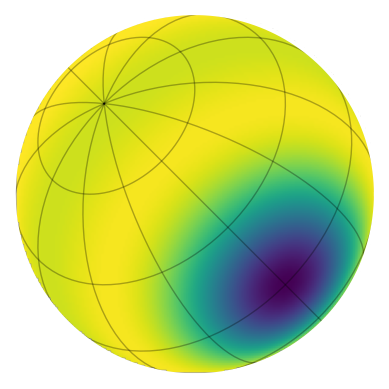

In [ ]:
spot_surface = Surface(y=er, inc=jnp.pi/4, obl = jnp.pi/4)
show_surface(spot_surface)

In [15]:
from jaxoplanet.starry.core import s2fft_rotation

In [16]:
def kron(m, n):
    """Kronecker delta. Can we do better?"""
    return m == n
def Umn(m, n):
    """Compute the (m, n) term of the transformation
    matrix from complex to real Ylms. This part is from starry"""
    if n < 0:
        term1 = 1j
    elif n == 0:
        term1 = jnp.sqrt(2) / 2
    else:
        term1 = 1
    if (m > 0) and (n < 0) and (n % 2 == 0):
        term2 = -1
    elif (m > 0) and (n > 0) and (n % 2 != 0):
        term2 = -1
    else:
        term2 = 1
    return term1 * term2 * 1 / jnp.sqrt(2) * (kron(m, n) + kron(m, -n) + 0j)

def U(l):
    """Compute the complete U transformation matrix.. This part is from starry"""
    res = jnp.zeros((2 * l + 1, 2 * l + 1)) + 0j
    for m in range(-l, l + 1):
        for n in range(-l, l + 1):
            res = res.at[m + l, n + l].set(Umn(m, n))
    return res

In [17]:
er_array = jnp.array([er[l,m] for m in range(-l,l+1)])

In [18]:
er_array

Array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.00035045,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ], dtype=float32)

In [19]:
ebar = U(l) @ er_array

In [20]:
p_array = jnp.array([plphim(l,m,ebar,5.0,5.0) for m in range(-l,l+1)])

In [21]:
jnp.real(jnp.conj(U(l).T) @ p_array)

Array([ 0.00000000e+00,  3.32723883e-11,  0.00000000e+00,  4.11649577e-12,
        0.00000000e+00, -1.43987845e-05,  0.00000000e+00, -4.70872255e-05,
        0.00000000e+00, -1.90295905e-04,  0.00000000e+00], dtype=float32)

In [155]:
alpha = 96.0
beta = 4.0
lmax = 15
r = 0.1
c = 1.0
er = ylm.ylm_spot(lmax)(c, r)
ephis = []
for l in range(0, lmax+1):
    u = U(l)
    erl = jnp.array([er[l,m] for m in range(-l,l+1)])
    erlbar = u @ erl
    p = jnp.array([plphim(l, m, erlbar, alpha, beta) for m in range(-l, l+1)])
    ephis.append(jnp.real(jnp.conj(u.T) @ p))
ephi = jnp.concatenate(ephis)

In [158]:
er.data

{(0, 0): Array(0.99709123, dtype=float32),
 (1, -1): Array(0., dtype=float32),
 (1, 0): Array(-0.0047899, dtype=float32),
 (1, 1): Array(0., dtype=float32),
 (2, -2): Array(0., dtype=float32),
 (2, -1): Array(0., dtype=float32),
 (2, 0): Array(-0.00615147, dtype=float32),
 (2, 1): Array(0., dtype=float32),
 (2, 2): Array(0., dtype=float32),
 (3, -3): Array(0., dtype=float32),
 (3, -2): Array(0., dtype=float32),
 (3, -1): Array(0., dtype=float32),
 (3, 0): Array(-0.00665448, dtype=float32),
 (3, 1): Array(0., dtype=float32),
 (3, 2): Array(0., dtype=float32),
 (3, 3): Array(0., dtype=float32),
 (4, -4): Array(0., dtype=float32),
 (4, -3): Array(0., dtype=float32),
 (4, -2): Array(0., dtype=float32),
 (4, -1): Array(0., dtype=float32),
 (4, 0): Array(-0.00725344, dtype=float32),
 (4, 1): Array(0., dtype=float32),
 (4, 2): Array(0., dtype=float32),
 (4, 3): Array(0., dtype=float32),
 (4, 4): Array(0., dtype=float32),
 (5, -5): Array(0., dtype=float32),
 (5, -4): Array(0., dtype=float32),


In [156]:
ephi

Array([ 9.97090220e-01,  0.00000000e+00, -4.59829997e-03,  0.00000000e+00,
       -3.63351640e-11,  0.00000000e+00, -5.43157244e-03,  0.00000000e+00,
        4.15625866e-04,  0.00000000e+00, -8.35612551e-11,  0.00000000e+00,
       -5.15431864e-03,  0.00000000e+00,  9.55829280e-04,  0.00000000e+00,
        6.99917901e-12,  0.00000000e+00, -1.47417190e-10,  0.00000000e+00,
       -4.66076285e-03,  0.00000000e+00,  1.68625603e-03,  0.00000000e+00,
       -4.00306417e-05,  0.00000000e+00,  1.91960874e-11,  0.00000000e+00,
       -2.00690492e-10,  0.00000000e+00, -3.49344895e-03,  0.00000000e+00,
        2.29563168e-03,  0.00000000e+00, -1.09788823e-04,  0.00000000e+00,
       -9.61364303e-14,  0.00000000e+00,  4.04935044e-11,  0.00000000e+00,
       -2.59446326e-10,  0.00000000e+00, -2.46326718e-03,  0.00000000e+00,
        2.96772015e-03,  0.00000000e+00, -2.31595841e-04,  0.00000000e+00,
        4.03091781e-06,  0.00000000e+00, -2.92599468e-13,  0.00000000e+00,
        6.44717960e-11,  

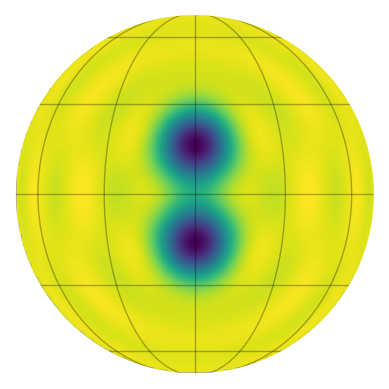

In [63]:
show_surface(ephi)

# Longitude integrals

In [64]:
def qllambda(l, i):
    if (i % 2) != 0:
        return 0.0
    else:
        term1 = 2 ** l * jnp.exp(jax.lax.lgamma((1 + i) / 2) + jax.lax.lgamma(l + (1 - i) / 2)) 
        term2 = jnp.pi * jnp.exp(jax.lax.lgamma(float(l + 1)))

        return term1 / term2

In [65]:
[qllambda(5.0,ii) for ii in range(11)]

[Array(7.8750076, dtype=float32, weak_type=True),
 0.0,
 Array(0.87500083, dtype=float32, weak_type=True),
 0.0,
 Array(0.3749997, dtype=float32, weak_type=True),
 0.0,
 Array(0.3749997, dtype=float32, weak_type=True),
 0.0,
 Array(0.87500083, dtype=float32, weak_type=True),
 0.0,
 Array(7.8750076, dtype=float32, weak_type=True)]

In [66]:
def pllambdam(l, m, ebarphi):
    sumterm = sum([ebarphi[l+mp] * clmmpi(l, m, mp, i) * qllambda(l, i) for mp in range(-l, l+1) for i in range(0, 2*l+1)])

    return sumterm 

In [ ]:
alpha = 5*jnp.sqrt(3)
beta = 10-alpha
lmax = 5
r = 0.1
c = 0.5
er = ylm.ylm_spot(lmax)(c, r)
elambdas = []
ephis = []
for l in range(0, lmax+1):
    u = U(l)
    erl = jnp.array([er[l,m] for m in range(-l,l+1)])
    erlbar = u @ erl
    p = jnp.array([plphim(l, m, erlbar, alpha, beta) for m in range(-l, l+1)])

    ephi = jnp.real(jnp.conj(u.T) @ p)
    ephis.append(ephi)
    ebarphi = u @ ephi

    plambda = jnp.array([pllambdam(l, m, ebarphi) for m in range(-l, l+1)])
    elambdas.append(jnp.real(jnp.conj(u.T) @ plambda))

elambda = jnp.concatenate(elambdas)
ephis_full = jnp.concatenate(ephis)

In [170]:
elambda

Array([ 9.9657375e-01,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -3.7400314e-04,  0.0000000e+00,
       -6.4780156e-04,  0.0000000e+00,  6.8691546e-17,  0.0000000e+00,
       -1.4551915e-10,  0.0000000e+00,  1.6463612e-10,  0.0000000e+00,
        7.9731244e-18,  0.0000000e+00, -5.6425192e-17,  0.0000000e+00,
        2.2440313e-04,  0.0000000e+00,  3.3452048e-04,  0.0000000e+00,
        4.4252898e-04,  0.0000000e+00, -1.9626156e-16,  0.0000000e+00,
        1.1162376e-16,  0.0000000e+00, -2.1827873e-10,  0.0000000e+00,
       -4.4245957e-10,  0.0000000e+00, -1.2347709e-10,  0.0000000e+00],      dtype=float32)

In [68]:
ephis_full.shape

(256,)

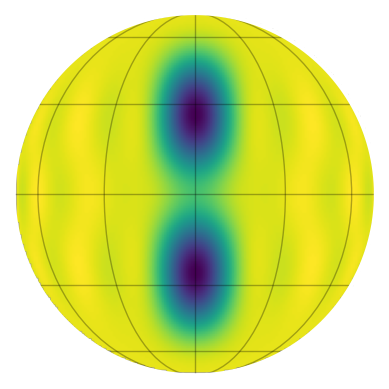

In [69]:
show_surface(ephis_full)

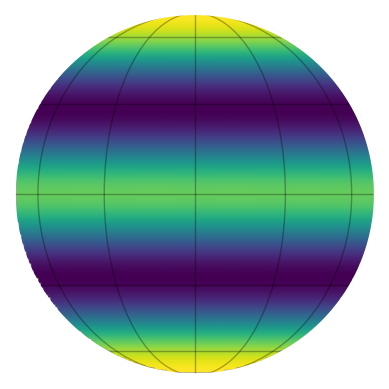

In [70]:
show_surface(elambda)

# Second moment integrals

In [101]:
def clmmpi(l, m, mp, i):
    if (m - mp - i) % 2 != 0:
        return 0.0

    if i < max(0, m + mp, -m - mp):
        return 0.0
    if i > min(2*l, 2*l + m - mp, 2*l - m + mp):
        return 0.0

    a = (i - m - mp) // 2
    b = (i + m + mp) // 2
    c = (2*l - i - m + mp) // 2
    d = (2*l - i + m - mp) // 2

    log_num = 0.5 * (
        log_factorial(l - m) +
        log_factorial(l + m) +
        log_factorial(l - mp) +
        log_factorial(l + mp)
    )

    log_denom = (
        l * jnp.log(2) +
        log_factorial(a) +
        log_factorial(b) +
        log_factorial(c) +
        log_factorial(d)
    )

    k = (2*l - m + mp - i) // 2
    sign = 1 if (k % 2 == 0) else -1

    return sign * jnp.exp(log_num - log_denom)

In [102]:
def Qllp(l, lp, i, ip, alpha, beta):
    if (i+ip) % 2 != 0:
        return 0.0
    else:
        logterm1_num = jax.lax.lgamma(alpha) + jax.lax.lgamma(l + lp + beta - (i + ip) / 2)
        logterm1_denom = jax.lax.lgamma(l + lp + alpha + beta - (i + ip) / 2)
        term1 = jnp.exp(logterm1_num - logterm1_denom)
        term2 = jax.scipy.special.hyp2f1(-(i + ip) / 2, alpha, l + lp + alpha + beta - (i + ip) / 2, -1)

        return term1 * term2

In [103]:
def Pllpmmp(l, lp, m, mp, alpha, beta, ebar, ebarp):
    term1 = jnp.exp(jax.lax.lgamma(alpha + beta) - (jax.lax.lgamma(alpha) + jax.lax.lgamma(beta)))
    term2 = ebar[l] * ebarp[lp] * jnp.exp(1j * jnp.pi / 2 * (m + mp)) # ebar[l] == ebar(l=l, m=0), ebarp[lp] == ebar(l=lp,m=0)
    sumterm = sum([(clmmpi(l, m, 0, i) * clmmpi(lp, mp, 0, ip) * Qllp(l, lp, i, ip, alpha, beta)) for i in range(0, 2*l+1) for ip in range(0, 2*lp+1)])

    return term1 * term2 * sumterm

In [73]:
er = ylm.ylm_spot(15)(contrast=0.1, r=0.1)

In [74]:
def ebar_func(er, l):
    er_array = jnp.array([er[l,m] for m in range(-l,l+1)])
    ebar = U(l) @ er_array

    return ebar

In [161]:
alpha = 5*jnp.sqrt(3)
beta = 10-alpha
lmax = 5
r = 0.1
c = 0.5
er = ylm.ylm_spot(lmax)(c, r)

Ellphis = np.zeros((jnp.square(lmax+1), jnp.square(lmax+1)))
for l in range(0, lmax+1):
    ul = U(l)
    erbarl = ebar_func(er, l)
    for lp in range(0, lmax+1):
        ulp = U(lp)
        erbarlp = ebar_func(er, lp)
        pllp = np.zeros((2*l+1,2*lp+1), dtype=np.complex128)
        for m in range(-l, l+1):
            for mp in range(-lp, lp+1):
                pllp[l + m, lp + mp] = Pllpmmp(l, lp, m, mp, alpha, beta, erbarl, erbarlp)
        Ellphis[l**2:l**2+2*l+1, lp**2:lp**2+2*lp+1] = jnp.conj(ul.T) @ pllp @ jnp.conj(ulp.T).T

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_19434/3217624605.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  Ellphis[l**2:l**2+2*l+1, lp**2:lp**2+2*lp+1] = jnp.conj(ul.T) @ pllp @ jnp.conj(ulp.T).T


In [174]:
jnp.log(Ellphis.conj().T)

Array([[-6.8608499e-03,           -inf,            nan, ...,
                  -inf,            nan,           -inf],
       [          -inf, -1.2297825e+01,           -inf, ...,
                   nan,           -inf, -3.1548651e+01],
       [           nan,           -inf, -1.1142141e+01, ...,
                  -inf, -1.4029091e+01,           -inf],
       ...,
       [          -inf,            nan,           -inf, ...,
                   nan,           -inf,            nan],
       [           nan,           -inf, -1.4029091e+01, ...,
                  -inf, -1.5884572e+01,           -inf],
       [          -inf, -3.1548651e+01,           -inf, ...,
                   nan,           -inf,            nan]], dtype=float32)

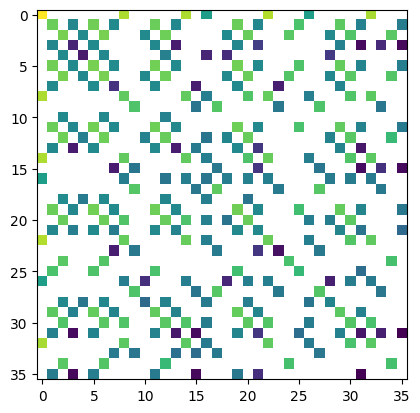

In [164]:
plt.imshow(jnp.log(Ellphis.conj().T))

In [173]:
jnp.log(Ellphis.conj().T)

Array([[-6.8608499e-03,           -inf,            nan, ...,
                  -inf,            nan,           -inf],
       [          -inf, -1.2297825e+01,           -inf, ...,
                   nan,           -inf, -3.1548651e+01],
       [           nan,           -inf, -1.1142141e+01, ...,
                  -inf, -1.4029091e+01,           -inf],
       ...,
       [          -inf,            nan,           -inf, ...,
                   nan,           -inf,            nan],
       [           nan,           -inf, -1.4029091e+01, ...,
                  -inf, -1.5884572e+01,           -inf],
       [          -inf, -3.1548651e+01,           -inf, ...,
                   nan,           -inf,            nan]], dtype=float32)

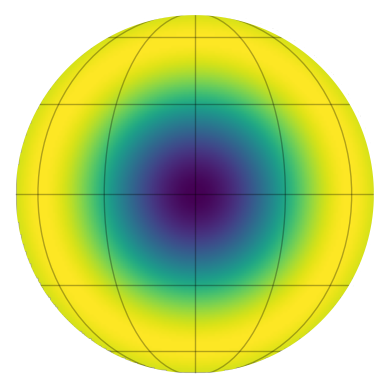

In [165]:
show_surface(er)

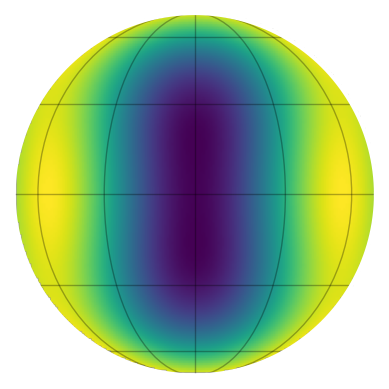

In [166]:
show_surface(jnp.real(Ellphis[:,0]))

In [176]:
Ellphis

array([[ 9.93162632e-01,  0.00000000e+00, -3.76697234e-03, ...,
         0.00000000e+00, -2.43171962e-04,  0.00000000e+00],
       [ 0.00000000e+00,  4.56165435e-06,  0.00000000e+00, ...,
        -1.80148973e-13,  0.00000000e+00,  1.98881727e-14],
       [-3.76697234e-03,  0.00000000e+00,  1.44887072e-05, ...,
         0.00000000e+00,  8.07687513e-07,  0.00000000e+00],
       ...,
       [ 0.00000000e+00, -1.80148973e-13,  0.00000000e+00, ...,
        -1.26959490e-14,  0.00000000e+00, -2.62171220e-22],
       [-2.43171962e-04,  0.00000000e+00,  8.07687513e-07, ...,
         0.00000000e+00,  1.26304315e-07,  0.00000000e+00],
       [ 0.00000000e+00,  1.98881727e-14,  0.00000000e+00, ...,
        -9.88275162e-16,  0.00000000e+00, -3.06712275e-24]],
      shape=(36, 36))

In [120]:
ephis_full @ ephis_full.T

Array(0.9971211, dtype=float32)

# Second moment Longitude integral

In [133]:
def Qllambda(l, lp, i, ip):
    if (i+ip) % 2 != 0:
        return 0.0
    else:
        return qllambda(l+lp, i+ip)

In [ ]:
def Pllambdammp(l, lp, m, mp, ebarphi, ebarphip):
    prefactor = ebarphi[l] * ebarphip[lp]
    sumterm = sum(clmmpi(l,m,0,i) * clmmpi(lp,mp,0,ip) * Qllambda(l,lp,i,ip) for i in range(2*l+1) for ip in range(2*lp+1))

    return prefactor * sumterm

In [ ]:
alpha = 5*jnp.sqrt(3)
beta  = 10-alpha

lmax = 5
er = ylm.ylm_spot(lmax)(0.5,0.1)

N=(lmax+1)**2

Ellphis   = np.zeros((N,N),dtype=np.complex128)
Ellambdas = np.zeros((N,N),dtype=np.complex128)


for l in range(lmax+1):

    Ul = U(l)
    erbarl = ebar_func(er,l)

    for lp in range(lmax+1):

        Ulp = U(lp)
        erbarlp = ebar_func(er,lp)

        # Latitude second moment

        Pphi = np.zeros((2*l+1,2*lp+1),dtype=np.complex128)

        for m in range(-l,l+1):
            for mp in range(-lp,lp+1):

                Pphi[l+m,lp+mp] = Pllpmmp(l,lp,m,mp,alpha,beta,erbarl,erbarlp)

        Ephi_block = (jnp.conj(Ul.T) @ Pphi @ jnp.conj(Ulp.T).T)

        Ellphis[l**2:l**2+2*l+1,lp**2:lp**2+2*lp+1] = Ephi_block

        # First longitude moment 

        ephi_l = jnp.real(jnp.conj(Ul.T) @ jnp.array([plphim(l,m,erbarl,alpha,beta) for m in range(-l,l+1)]))

        ephi_lp = jnp.real(jnp.conj(Ulp.T) @ jnp.array([plphim(lp,m,erbarlp,alpha,beta) for m in range(-lp,lp+1)]))

        ebarphi_l  = Ul @ ephi_l
        ebarphi_lp = Ulp @ ephi_lp

        # Longitude second moment

        Plam = np.zeros((2*l+1,2*lp+1), dtype=np.complex128)

        for m in range(-l,l+1):
            for mp in range(-lp,lp+1):

                Plam[l+m,lp+mp] = Pllambdammp(l,lp,m,mp,ebarphi_l,ebarphi_lp)

        Ellambdas[l**2:l**2+2*l+1,lp**2:lp**2+2*lp+1] = jnp.conj(Ul.T) @ Plam @ jnp.conj(Ulp.T).T

In [137]:
Ellphis.shape

(36, 36)

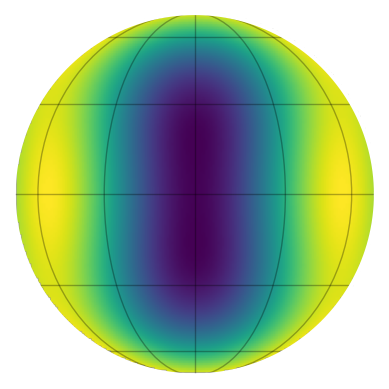

In [138]:
show_surface(jnp.real(Ellphis[:,0]))

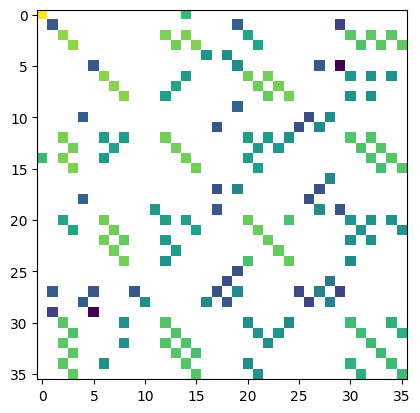

In [177]:
plt.imshow(jnp.log(jnp.real(Ellambdas)))

In [150]:
variance_matrix = jnp.real(Ellambdas) - elambda[:, None] * elambda[None, :]

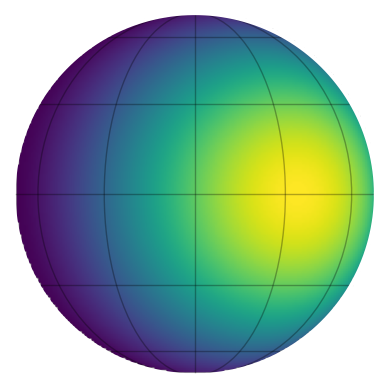

In [151]:
show_surface(jnp.diag(variance_matrix))

In [153]:
variance_matrix

Array([[ 7.7486038e-07,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  1.2305403e-10,  0.0000000e+00],
       [ 0.0000000e+00,  1.9185663e-22,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  7.1438667e-06, ...,
         0.0000000e+00,  2.5343542e-08,  0.0000000e+00],
       ...,
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         3.5712611e-10,  0.0000000e+00, -2.3455427e-11],
       [ 1.2305403e-10,  0.0000000e+00,  2.5343542e-08, ...,
         0.0000000e+00,  3.1467737e-10,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -2.3455427e-11,  0.0000000e+00,  2.8320990e-10]], dtype=float32)

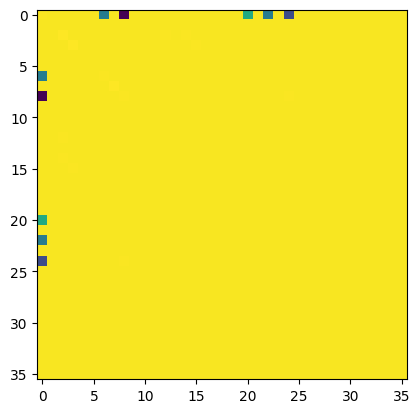

In [152]:
plt.imshow(variance_matrix)

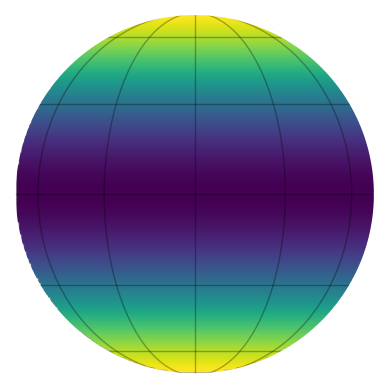

In [178]:
show_surface(jnp.real(Ellambdas[:,0]))

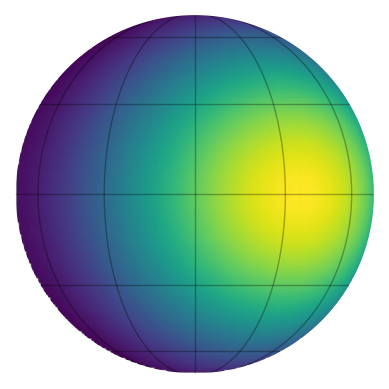

In [180]:
show_surface(jnp.real(jnp.diag(Ellambdas)))

In [182]:
elambda

Array([ 9.9657375e-01,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -3.7400314e-04,  0.0000000e+00,
       -6.4780156e-04,  0.0000000e+00,  6.8691546e-17,  0.0000000e+00,
       -1.4551915e-10,  0.0000000e+00,  1.6463612e-10,  0.0000000e+00,
        7.9731244e-18,  0.0000000e+00, -5.6425192e-17,  0.0000000e+00,
        2.2440313e-04,  0.0000000e+00,  3.3452048e-04,  0.0000000e+00,
        4.4252898e-04,  0.0000000e+00, -1.9626156e-16,  0.0000000e+00,
        1.1162376e-16,  0.0000000e+00, -2.1827873e-10,  0.0000000e+00,
       -4.4245957e-10,  0.0000000e+00, -1.2347709e-10,  0.0000000e+00],      dtype=float32)

In [184]:
jnp.real(Ellambdas)

Array([[ 9.9316001e-01,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  1.9185663e-22,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  7.1438667e-06, ...,
         0.0000000e+00,  2.5343542e-08,  0.0000000e+00],
       ...,
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         3.5712611e-10,  0.0000000e+00, -2.3455427e-11],
       [ 0.0000000e+00,  0.0000000e+00,  2.5343542e-08, ...,
         0.0000000e+00,  3.1467737e-10,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -2.3455427e-11,  0.0000000e+00,  2.8320990e-10]], dtype=float32)